##Step-1:-Import Libraries

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

sns.set_style("whitegrid")

In [5]:
import plotly.express as px
from textblob import TextBlob

##Step-2:-Load Dataset

In [6]:
df=pd.read_csv('/content/googleplaystore.csv')

In [7]:
df.head(3)

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up


In [8]:
df.shape


(10841, 13)

In [9]:
df.columns

Index(['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type',
       'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver',
       'Android Ver'],
      dtype='object')

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.1+ MB


In [11]:
df.describe(include='all')

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
count,10841,10841,9367.000000,10841,10841,10841,10840,10841,10840,10841,10841,10833,10838
unique,9660,34,NaN,6002,462,22,3,93,6,120,1378,2832,33
top,ROBLOX,FAMILY,NaN,0,Varies with device,"1,000,000+",Free,0,Everyone,Tools,"August 3, 2018",Varies with device,4.1 and up
freq,9,1972,NaN,596,1695,1579,10039,10040,8714,842,326,1459,2451
mean,NaN,NaN,4.193338,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,0.537431,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,4.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,4.300000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,4.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [12]:
df.isnull().sum()

,0
App,0
Category,0
Rating,1474
Reviews,0
Size,0
Installs,0
Type,1
Price,0
Content Rating,1
Genres,0


##Step-3:-Check duplicates

In [13]:
df.duplicated().sum()

np.int64(483)

In [14]:
df[df.duplicated()].head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
229,Quick PDF Scanner + OCR FREE,BUSINESS,4.2,80805,Varies with device,"5,000,000+",Free,0,Everyone,Business,"February 26, 2018",Varies with device,4.0.3 and up
236,Box,BUSINESS,4.2,159872,Varies with device,"10,000,000+",Free,0,Everyone,Business,"July 31, 2018",Varies with device,Varies with device
239,Google My Business,BUSINESS,4.4,70991,Varies with device,"5,000,000+",Free,0,Everyone,Business,"July 24, 2018",2.19.0.204537701,4.4 and up
256,ZOOM Cloud Meetings,BUSINESS,4.4,31614,37M,"10,000,000+",Free,0,Everyone,Business,"July 20, 2018",4.1.28165.0716,4.0 and up
261,join.me - Simple Meetings,BUSINESS,4.0,6989,Varies with device,"1,000,000+",Free,0,Everyone,Business,"July 16, 2018",4.3.0.508,4.4 and up


In [15]:
df=df.drop_duplicates()

In [16]:
df.duplicated().sum()

np.int64(0)

##Step-4:-Fix the corrupted 1.9 category row

In [17]:
 df = df[df["Category"] != "1.9"]

In [18]:
df['Category'].unique()

array(['ART_AND_DESIGN', 'AUTO_AND_VEHICLES', 'BEAUTY',
       'BOOKS_AND_REFERENCE', 'BUSINESS', 'COMICS', 'COMMUNICATION',
       'DATING', 'EDUCATION', 'ENTERTAINMENT', 'EVENTS', 'FINANCE',
       'FOOD_AND_DRINK', 'HEALTH_AND_FITNESS', 'HOUSE_AND_HOME',
       'LIBRARIES_AND_DEMO', 'LIFESTYLE', 'GAME', 'FAMILY', 'MEDICAL',
       'SOCIAL', 'SHOPPING', 'PHOTOGRAPHY', 'SPORTS', 'TRAVEL_AND_LOCAL',
       'TOOLS', 'PERSONALIZATION', 'PRODUCTIVITY', 'PARENTING', 'WEATHER',
       'VIDEO_PLAYERS', 'NEWS_AND_MAGAZINES', 'MAPS_AND_NAVIGATION'],
      dtype=object)

##Step-5:-Clean the Reviews column

In [19]:
df["Reviews"] = df["Reviews"].astype(str).str.replace("M", "e6", regex=False)
df["Reviews"] = pd.to_numeric(df["Reviews"], errors="coerce")

In [20]:
df["Reviews"].dtype

dtype('int64')

##Step-6:-Clean the Installs column

In [21]:
df["Installs"] = (
    df["Installs"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .str.replace("+", "", regex=False)
)

In [22]:
df["Installs"] = pd.to_numeric(df["Installs"], errors="coerce")

In [23]:
df["Installs"].head()

,Installs
0,10000
1,500000
2,5000000
3,50000000
4,100000


##Step-7:-Clean size

In [24]:
def convert_size(size):
    if pd.isna(size):
        return np.nan

    size = str(size)

    if size == "Varies with device":
        return np.nan

    if size.endswith("M"):
        return float(size.replace("M", ""))

    if size.endswith("k"):
        return float(size.replace("k", "")) / 1024

    return np.nan

In [25]:
df["Size_MB"] = df["Size"].apply(convert_size)

In [26]:
df[["Size", "Size_MB"]].head(10)

,Size,Size_MB
0,19M,19.0
1,14M,14.0
2,8.7M,8.7
3,25M,25.0
4,2.8M,2.8
5,5.6M,5.6
6,19M,19.0
7,29M,29.0
8,33M,33.0
9,3.1M,3.1


##Step-8:-Clean Price

In [27]:
df["Price"] = df["Price"].astype(str).str.replace("$", "", regex=False)

In [28]:
df["Price"] = pd.to_numeric(df["Price"], errors="coerce")

##Step-9:-Handle missing ratings

In [29]:
df['Rating'].isnull().sum()

np.int64(1465)

##Step-10:-Final cleaning check

In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10357 entries, 0 to 10840
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10357 non-null  object 
 1   Category        10357 non-null  object 
 2   Rating          8892 non-null   float64
 3   Reviews         10357 non-null  int64  
 4   Size            10357 non-null  object 
 5   Installs        10357 non-null  int64  
 6   Type            10356 non-null  object 
 7   Price           10357 non-null  float64
 8   Content Rating  10357 non-null  object 
 9   Genres          10357 non-null  object 
 10  Last Updated    10357 non-null  object 
 11  Current Ver     10349 non-null  object 
 12  Android Ver     10355 non-null  object 
 13  Size_MB         8831 non-null   float64
dtypes: float64(3), int64(2), object(9)
memory usage: 1.2+ MB


In [31]:
df.isnull().sum()

,0
App,0
Category,0
Rating,1465
Reviews,0
Size,0
Installs,0
Type,1
Price,0
Content Rating,0
Genres,0


In [32]:
df.describe()

,Rating,Reviews,Installs,Price,Size_MB
count,8892.000000,1.035700e+04,1.035700e+04,10357.000000,8831.000000
mean,4.187877,4.059046e+05,1.415776e+07,1.030800,21.287413
std,0.522377,2.696778e+06,8.023955e+07,16.278625,22.540591
min,1.000000,0.000000e+00,0.000000e+00,0.000000,0.008301
25%,4.000000,3.200000e+01,1.000000e+03,0.000000,4.700000
50%,4.300000,1.680000e+03,1.000000e+05,0.000000,13.000000
75%,4.500000,4.641600e+04,1.000000e+06,0.000000,29.000000
max,5.000000,7.815831e+07,1.000000e+09,400.000000,100.000000


##Step-11:-Category Analysis

In [33]:
category_counts = df["Category"].value_counts()
category_counts

,count
Category,
FAMILY,1943
GAME,1121
TOOLS,843
BUSINESS,427
MEDICAL,408
PRODUCTIVITY,407
PERSONALIZATION,388
LIFESTYLE,373
COMMUNICATION,366


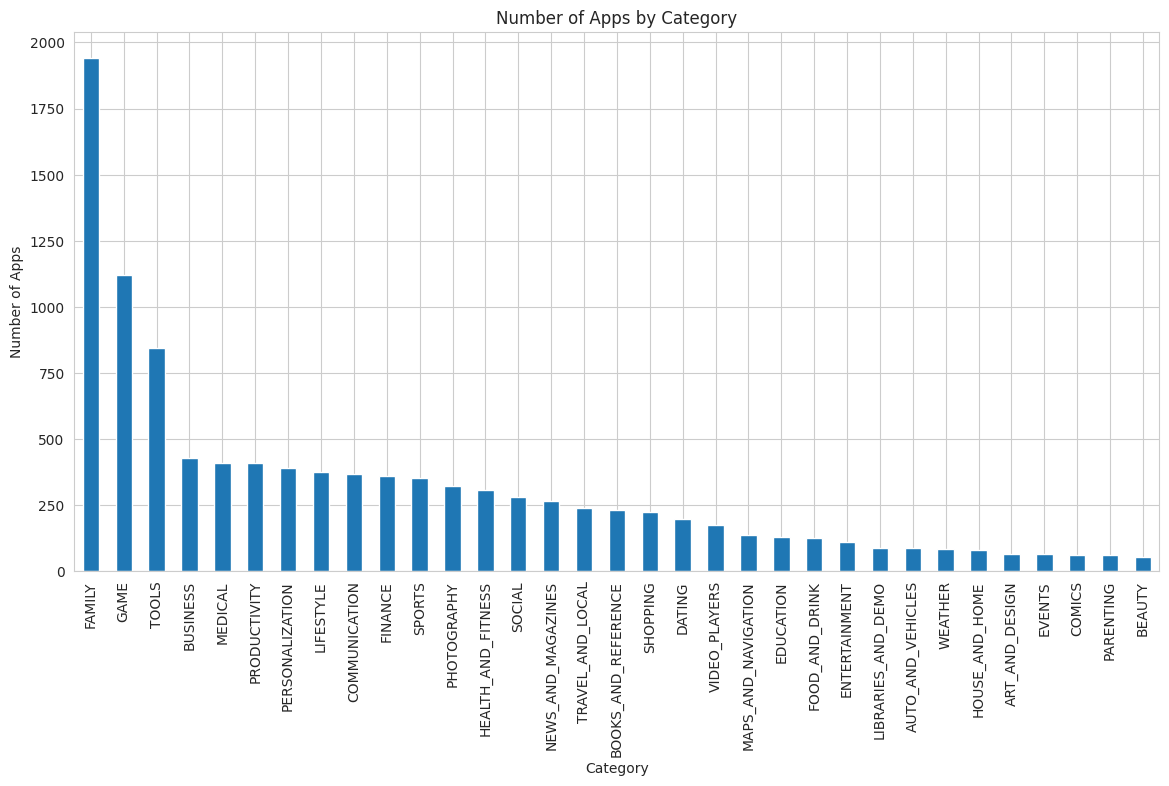

In [34]:
plt.figure(figsize=(14,7))

category_counts.plot(kind="bar")

plt.title("Number of Apps by Category")
plt.xlabel("Category")
plt.ylabel("Number of Apps")
plt.xticks(rotation=90)

plt.show()

##insight:-

* The category has high app concentration, suggesting stronger competition and potentially higher difficulty for new entrants.

##Step-12:-Rating Analysis

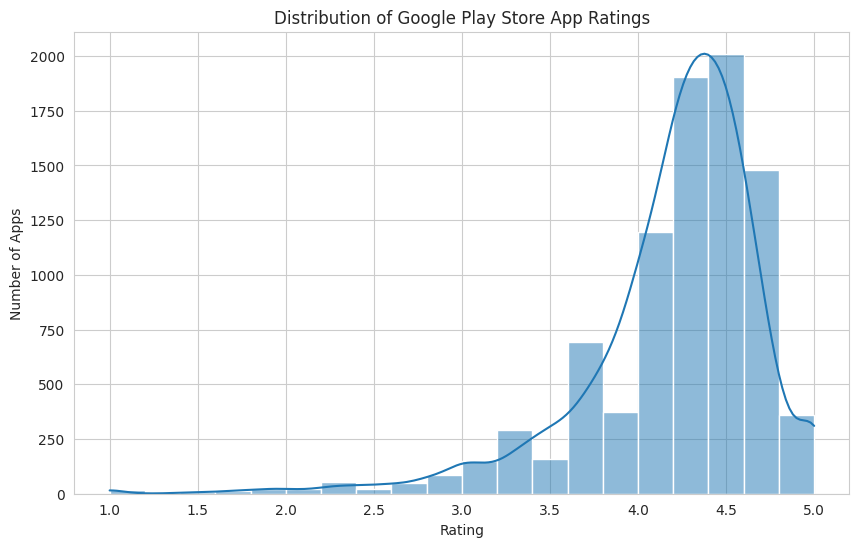

In [35]:
plt.figure(figsize=(10,6))

sns.histplot(df["Rating"].dropna(), bins=20, kde=True)

plt.title("Distribution of Google Play Store App Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Apps")

plt.show()

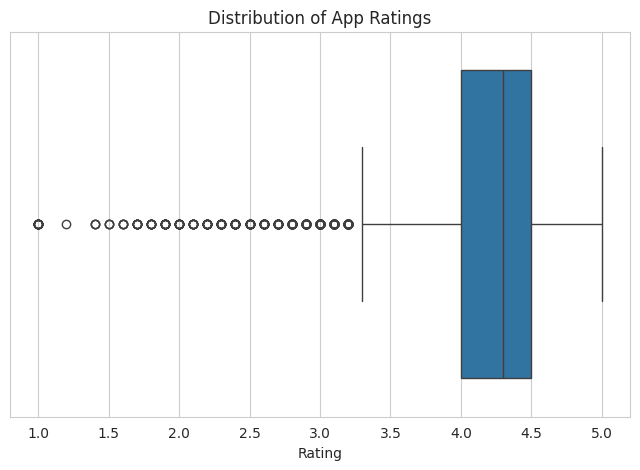

In [36]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df["Rating"])

plt.title("Distribution of App Ratings")
plt.xlabel("Rating")

plt.show()

##Step-13:-Average rating by category

In [37]:
category_rating = (
    df.groupby("Category")["Rating"]
    .mean()
    .sort_values(ascending=False)
)

In [38]:
category_rating

,Rating
Category,
EVENTS,4.435556
EDUCATION,4.375969
ART_AND_DESIGN,4.358065
BOOKS_AND_REFERENCE,4.347458
PERSONALIZATION,4.333871
PARENTING,4.300000
GAME,4.281285
BEAUTY,4.278571
HEALTH_AND_FITNESS,4.261450


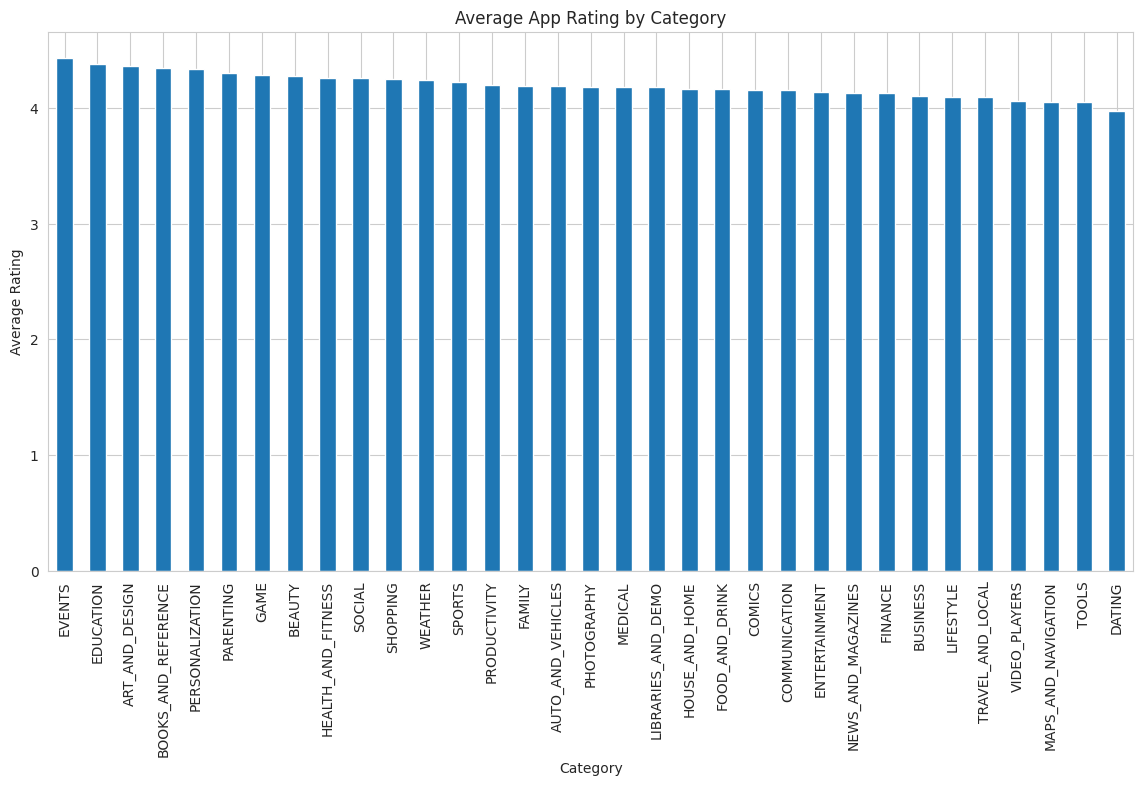

In [39]:
plt.figure(figsize=(14,7))

category_rating.plot(kind="bar")

plt.title("Average App Rating by Category")
plt.xlabel("Category")
plt.ylabel("Average Rating")
plt.xticks(rotation=90)

plt.show()

In [40]:
category_summary = df.groupby("Category").agg(
    App_Count=("App", "count"),
    Average_Rating=("Rating", "mean")
)

category_summary.sort_values(
    "Average_Rating",
    ascending=False
).head(10)

,App_Count,Average_Rating
Category,,
EVENTS,64,4.435556
EDUCATION,130,4.375969
ART_AND_DESIGN,65,4.358065
BOOKS_AND_REFERENCE,230,4.347458
PERSONALIZATION,388,4.333871
PARENTING,60,4.300000
GAME,1121,4.281285
BEAUTY,53,4.278571
HEALTH_AND_FITNESS,306,4.261450


##Step-14:-Size vs Installs Analysis

In [41]:
size_install_df = df.dropna(subset=["Size_MB", "Installs"])

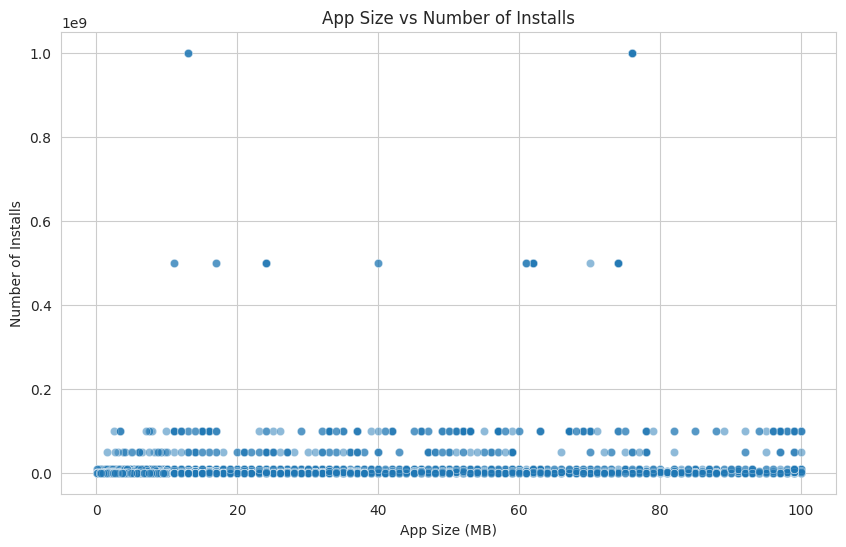

In [42]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=size_install_df,
    x="Size_MB",
    y="Installs",
    alpha=0.5
)

plt.title("App Size vs Number of Installs")
plt.xlabel("App Size (MB)")
plt.ylabel("Number of Installs")

plt.show()

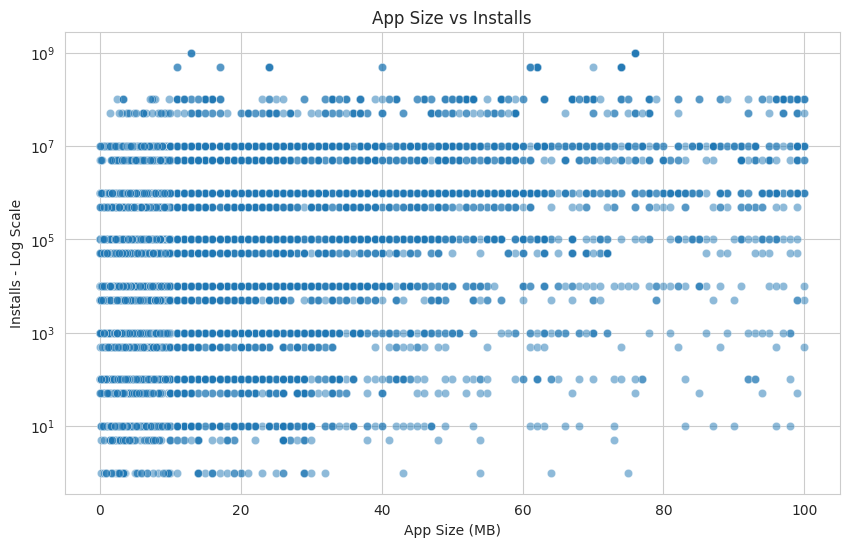

In [43]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=size_install_df,
    x="Size_MB",
    y="Installs",
    alpha=0.5
)

plt.yscale("log")

plt.title("App Size vs Installs")
plt.xlabel("App Size (MB)")
plt.ylabel("Installs - Log Scale")

plt.show()

In [44]:
correlation = size_install_df["Size_MB"].corr(
    size_install_df["Installs"]
)

print("Correlation:", correlation)

Correlation: 0.16887201973119803


##Step-15:-Free vs Paid Apps

In [45]:
df["Type"].value_counts()

,count
Type,
Free,9591
Paid,765


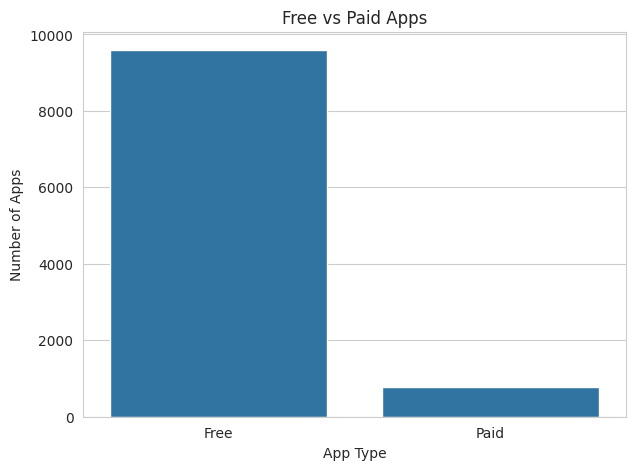

In [46]:
plt.figure(figsize=(7,5))

sns.countplot(data=df, x="Type")

plt.title("Free vs Paid Apps")
plt.xlabel("App Type")
plt.ylabel("Number of Apps")

plt.show()

In [47]:
type_percentage = df["Type"].value_counts(normalize=True) * 100
type_percentage

,proportion
Type,
Free,92.612978
Paid,7.387022


##Step-16:-Price Distribution of paid Apps

In [48]:
paid_apps = df[df["Type"] == "Paid"].copy()

In [49]:
paid_apps["Price"].describe()

,Price
count,765.000000
mean,13.955556
std,58.406966
min,0.990000
25%,1.490000
50%,2.990000
75%,4.990000
max,400.000000


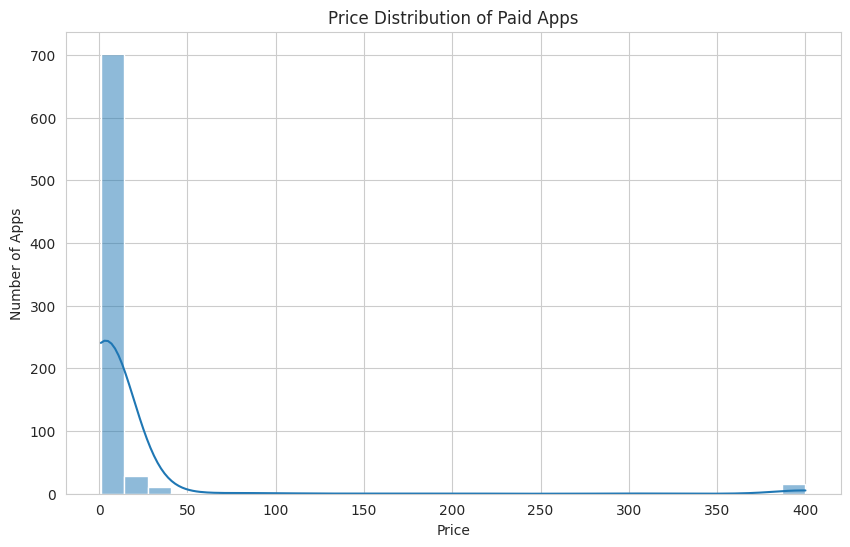

In [50]:
plt.figure(figsize=(10,6))

sns.histplot(
    paid_apps["Price"],
    bins=30,
    kde=True
)

plt.title("Price Distribution of Paid Apps")
plt.xlabel("Price")
plt.ylabel("Number of Apps")

plt.show()

In [51]:
paid_apps.sort_values(
    "Price",
    ascending=False
)[["App", "Category", "Price"]].head(10)

,App,Category,Price
4367,I'm Rich - Trump Edition,LIFESTYLE,400.00
5356,I Am Rich Premium,FINANCE,399.99
5369,I am Rich,FINANCE,399.99
5351,I am rich,LIFESTYLE,399.99
5354,I am Rich Plus,FAMILY,399.99
5358,I am Rich!,FINANCE,399.99
4362,💎 I'm rich,LIFESTYLE,399.99
4197,most expensive app (H),FAMILY,399.99
9934,I'm Rich/Eu sou Rico/أنا غني/我很有錢,LIFESTYLE,399.99
5373,I AM RICH PRO PLUS,FINANCE,399.99


##Step-17:-Estimated Revenue

In [52]:
df["Estimated_Revenue"] = df["Price"] * df["Installs"]

In [53]:
revenue_by_category = (
    df.groupby("Category")["Estimated_Revenue"]
    .sum()
    .sort_values(ascending=False)
)

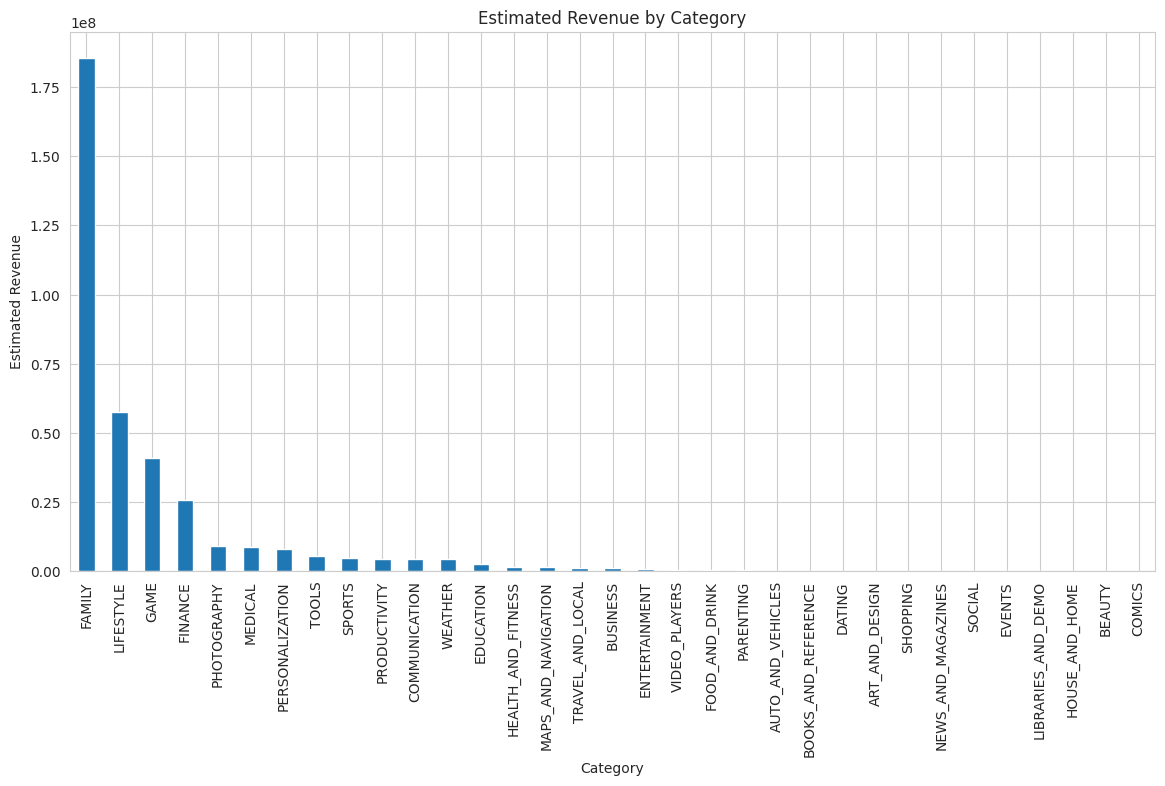

In [54]:
plt.figure(figsize=(14,7))

revenue_by_category.plot(kind="bar")

plt.title("Estimated Revenue by Category")
plt.xlabel("Category")
plt.ylabel("Estimated Revenue")

plt.xticks(rotation=90)

plt.show()

* Estimated revenue is calculated as Price × Installs and should be interpreted as a directional estimate rather than actual developer revenue.

##Step-18:-Interactive Plotly Visualization

In [55]:
fig = px.bar(
    category_counts.reset_index(),
    x="Category",
    y="count",
    title="Interactive App Distribution by Category"
)

fig.update_layout(
    xaxis_tickangle=-90
)

fig.show()

##Step-19:-User Reviews Sentiment Analysis

In [56]:
reviews = pd.read_csv("googleplaystore_user_reviews.csv")

In [ ]:
reviews.head()

##Step-20:-Sentiment Classification

In [ ]:
reviews['Sentiment'].value_counts()

In [ ]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=reviews,
    x="Sentiment"
)

plt.title("User Review Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")

plt.show()

##Step-21:-TextBlob Sentiment Analysis

In [ ]:
from textblob import TextBlob

In [ ]:
def get_polarity(text):
    if pd.isna(text):
        return np.nan
    return TextBlob(str(text)).sentiment.polarity

In [ ]:
reviews["Polarity"] = reviews["Translated_Review"].apply(get_polarity)

In [ ]:
def classify_sentiment(polarity):
    if pd.isna(polarity):
        return np.nan
    elif polarity > 0:
        return "Positive"
    elif polarity < 0:
        return "Negative"
    else:
        return "Neutral"

In [ ]:
reviews["Sentiment_TextBlob"] = reviews["Polarity"].apply(
    classify_sentiment
)

In [ ]:
reviews["Sentiment_TextBlob"].value_counts()

##Step-22:-Merge App data and Review data

In [ ]:
merged_df = reviews.merge(
    df[["App", "Category"]],
    on="App",
    how="left"
)

In [ ]:
merged_df.head()

##Step-23:-Sentiment by Category

In [ ]:
sentiment_category = pd.crosstab(
    merged_df["Category"],
    merged_df["Sentiment_TextBlob"],
    normalize="index"
) * 100

In [ ]:
sentiment_category

In [ ]:
sentiment_category.plot(
    kind="bar",
    stacked=True,
    figsize=(15,7)
)

plt.title("Sentiment Distribution by App Category")
plt.xlabel("Category")
plt.ylabel("Percentage of Reviews")
plt.xticks(rotation=90)

plt.show()

In [ ]:
sentiment_category.sort_values(
    "Positive",
    ascending=False
).head(10)

In [ ]:
sentiment_category.sort_values(
    "Negative",
    ascending=False
).head(10)

##Step-24:-Find Apps with Strong Positive/Negative Feedback

In [ ]:
positive_apps = (
    merged_df[merged_df["Sentiment_TextBlob"] == "Positive"]
    .groupby("App")
    .size()
    .sort_values(ascending=False)
)

positive_apps.head(10)

In [ ]:
negative_apps = (
    merged_df[merged_df["Sentiment_TextBlob"] == "Negative"]
    .groupby("App")
    .size()
    .sort_values(ascending=False)
)

negative_apps.head(10)

##Step-25:-Create a Correlation Matrix

In [ ]:
numeric_cols = [
    "Rating",
    "Reviews",
    "Size_MB",
    "Installs",
    "Price",
    "Estimated_Revenue"
]

corr = df[numeric_cols].corr()

plt.figure(figsize=(10,7))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

##Step-26:-Final 3 Developer Insights

##Insight 1 — Market competition

* The category analysis shows that some categories contain substantially more applications than others. This indicates higher competition and saturation in those segments. A new developer should therefore identify a specific niche or underserved user need rather than entering a highly crowded category with a generic application.


##Insight 2 — Monetization

* The Play Store ecosystem is dominated by free applications, indicating that users generally have a low barrier to downloading apps. Developers launching a new application should consider a freemium strategy, advertising, subscriptions, or in-app purchases rather than relying exclusively on an upfront paid model.


##Insight 3 — User experience

* Rating and sentiment analysis can reveal which categories receive stronger or weaker user feedback. A developer should prioritize app stability, usability, performance, and features associated with negative reviews before launch, while incorporating characteristics commonly associated with positive user experiences.





TASK 4 - GOOGLE PLAY STORE ANALYSIS
│
├── 1. Business Objective
│
├── 2. Import Libraries
│
├── 3. Load Dataset
│
├── 4. Data Understanding
│   ├── Shape
│   ├── Columns
│   ├── Data Types
│   └── Missing Values
│
├── 5. Data Cleaning
│   ├── Remove Duplicates
│   ├── Fix Corrupted Row
│   ├── Clean Reviews
│   ├── Clean Installs
│   ├── Clean Size
│   └── Clean Price
│
├── 6. Category Analysis
│   ├── App Distribution
│   └── Category Saturation
│
├── 7. Ratings Analysis
│   ├── Rating Distribution
│   └── Average Rating by Category
│
├── 8. Size & Installs Analysis
│   ├── Scatter Plot
│   └── Correlation
│
├── 9. Pricing Analysis
│   ├── Free vs Paid
│   ├── Paid App Price Distribution
│   └── Estimated Revenue
│
├── 10. User Review Analysis
│   ├── Load Reviews Dataset
│   ├── TextBlob/VADER
│   ├── Positive
│   ├── Negative
│   └── Neutral
│
├── 11. Sentiment by Category
│
├── 12. Interactive Plotly Visualization
│
├── 13. Key Findings
│
└── 14. Final Recommendations